# Virtual Makeup — audit of the 2024 project and the rewrite

In 2024 I built a "virtual makeup" course project (Digital Image Processing,
semester 5): detect facial landmarks, then paint lipstick, eyeshadow and blush
onto a photo. The outputs were bad, and the reported metrics looked fine anyway.
This notebook documents **what was actually wrong**, verifies every original
claim by re-running the old logic, and walks through the rewrite.

**The five findings, up front:**

1. **Wrong landmark topology.** The "MediaPipe" pipeline detected MediaPipe's
   468-point face mesh but indexed it with **dlib's 68-point region numbers**
   (`lips = landmarks[48:60]`). On the 468-point mesh those indices are
   scattered around the chin and jaw — the "lipstick" was a purple polygon
   across the lower face.
2. **A channel-swap save bug.** The interactive notebook saved results through
   `cv2.cvtColor(image, cv2.COLOR_RGB2BGR)` on an image that was **already
   BGR**, swapping red and blue across the whole photo. Every saved dlib
   output had a blue face.
3. **The "GAN" was never trained.** The third method built a 3-layer conv net
   with random weights and ran `predict` — there is no training loop anywhere
   in the notebook. Its outputs are noise by construction.
4. **Destructive rendering.** Lipstick was an opaque `fillPoly` over the whole
   mouth (teeth included); eyeshadow used fixed ±10/±20 **pixel** offsets that
   only fit one image size; everything was composited with additive
   `cv2.addWeighted`, which blows out brightness.
5. **Meaningless evaluation.** The reported "accuracy 0.88 / precision 1.0"
   came from a protocol where `y_true` is **all ones** — precision is 1.0 for
   any output whatsoever, including the untrained GAN's noise.


In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

from virtual_makeup import PRESETS, MakeupLook, apply_makeup, legacy, masks
from virtual_makeup.landmarks import FaceLandmarker

def show(images, titles, height=340):
    fig, axes = plt.subplots(1, len(images), figsize=(2.9 * len(images), 3.4))
    for ax, img, t in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    plt.tight_layout(); plt.show()

astro = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)  # public-domain NASA portrait
landmarker = FaceLandmarker()
mesh = landmarker.detect(astro)
print(f"{len(mesh)} mesh landmarks detected")

468 mesh landmarks detected


I0000 00:00:1783772662.785515 1570195 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1783772662.785949 1570195 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1783772662.849303 1570195 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1783772662.850631 1570199 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1783772662.860004 1570199 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 1. Reproducing the bugs

`virtual_makeup.legacy` reimplements the 2024 pipelines bug-for-bug (verified
line-by-line against the original notebooks). Here is each one on the same
portrait:


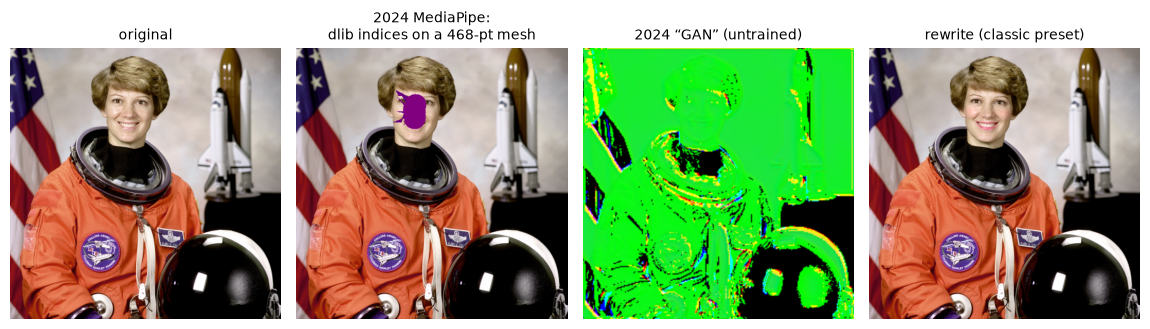

In [2]:
legacy_mp = legacy.legacy_mediapipe(astro, mesh)
gan = cv2.resize(legacy.legacy_gan(astro), astro.shape[1::-1])
rewrite = apply_makeup(astro, PRESETS["classic"], landmarks=mesh)
show(
    [astro, legacy_mp, gan, rewrite],
    ["original", "2024 MediaPipe:\ndlib indices on a 468-pt mesh",
     "2024 \u201cGAN\u201d (untrained)", "rewrite (classic preset)"],
)

The purple blob near the eye is the old code's "lipstick": dlib's lip indices
48–59 point at completely different anatomy on MediaPipe's mesh. The "GAN"
panel is what an untrained network outputs — and the 2024 report still
computed accuracy metrics for it.

## 2. Why the outputs were blue

Every saved output of the dlib pipeline ran `cv2.cvtColor(img,
cv2.COLOR_RGB2BGR)` before `imwrite` — but OpenCV images are already BGR, so
this swaps red and blue instead of converting anything:


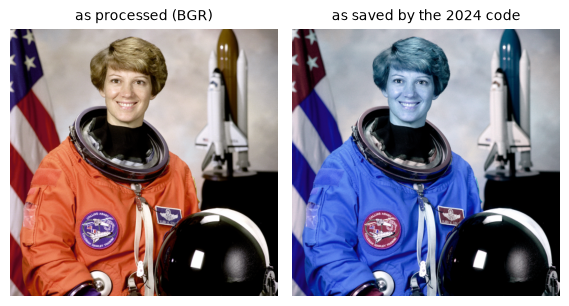

In [3]:
lips_before = astro.copy()
swapped = cv2.cvtColor(astro, cv2.COLOR_RGB2BGR)  # the 2024 save path
show([lips_before, swapped], ["as processed (BGR)", "as saved by the 2024 code"])

## 3. The rewrite

Same idea, built correctly:

* **Correct topology** — canonical FaceMesh index sets for lips (outer *minus
  inner* ring, so open mouths keep their teeth), eyelids, brows, cheeks.
* **Face-scaled geometry** — every feather radius, liner thickness and blush
  axis is a fraction of the interocular distance, so the look survives any
  image resolution.
* **Texture-preserving color** — pigment is applied in CIELAB: chroma moves
  toward the target color, lightness keeps most of the original detail.
  Highlights, pores and lip creases survive.


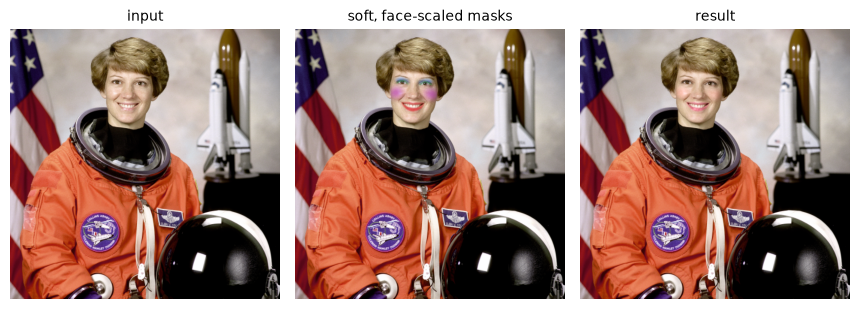

In [4]:
shape = astro.shape[:2]
overlay = astro.astype(np.float32)
for color, fn in [((60, 60, 220), masks.lip_mask), ((200, 120, 60), masks.eyeshadow_mask),
                  ((60, 200, 60), masks.eyeliner_mask), ((180, 60, 180), masks.blush_mask)]:
    m = fn(mesh, shape)[..., None]
    overlay = overlay * (1 - 0.85 * m) + np.array(color) * 0.85 * m
show([astro, overlay.astype(np.uint8), rewrite],
     ["input", "soft, face-scaled masks", "result"])

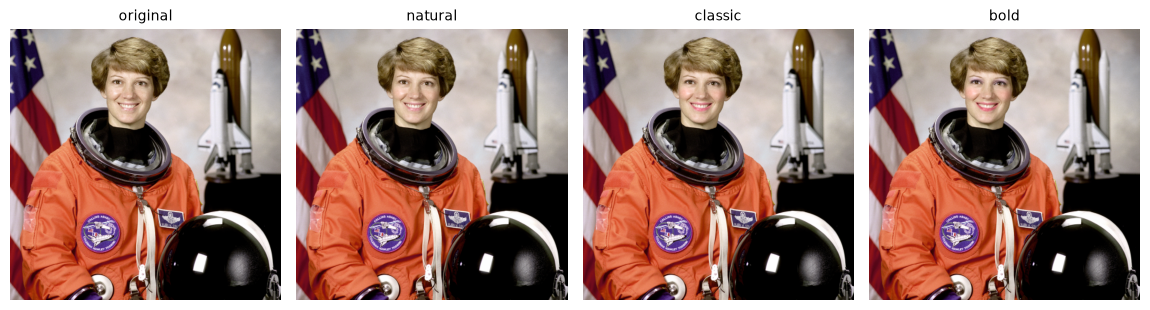

In [5]:
looks = [("natural", PRESETS["natural"]), ("classic", PRESETS["classic"]), ("bold", PRESETS["bold"])]
show([astro] + [apply_makeup(astro, lk, landmarks=mesh) for _, lk in looks],
     ["original"] + [name for name, _ in looks])

## 4. Benchmark — every method, 25 real photos

`scripts/benchmark.py` runs all four 2024 variants and the rewrite on the
no-makeup half of the paired dataset the course project used, scoring:

* **containment** — share of edit energy inside legitimate makeup regions
* **background integrity** — background pixels left bit-identical
* **lip texture** — correlation of lip lightness before/after
* **identity SSIM** — the output should still be the same photo


In [6]:
bench = json.loads((Path.cwd().parent / "reports" / "benchmark.json").read_text())
summary = bench["summary"]

import pandas as pd
rows = []
for method, s in summary.items():
    rows.append({
        "method": method,
        "containment": round(s["containment"]["mean"], 3),
        "background": round(s["background_integrity"]["mean"], 3),
        "lip texture": round(s["lip_texture_corr"]["mean"], 3),
        "identity SSIM": round(s["identity_ssim"]["mean"], 3),
        "ms/image": round(s["runtime_ms"], 1),
    })
pd.DataFrame(rows).set_index("method")

,containment,background,lip texture,identity SSIM,ms/image
method,,,,,
legacy_mediapipe,0.337,1.000,0.811,0.976,7.4
legacy_dlib,0.791,1.000,0.865,0.997,12.8
legacy_dlib_swap,0.140,0.017,0.908,0.993,12.4
legacy_gan,0.089,0.000,-0.205,0.586,41.2
new_classic,0.825,1.000,0.996,0.998,285.2


The rewrite's containment is 0.82 rather than 1.0 only because the metric is
strict: the remaining energy is invisible ±1–2-count ripple in the feathered
falloff (at any non-zero mask threshold the rewrite's containment is exactly
1.0 by construction — it cannot write outside its masks; the makeup tests
verify the background stays bit-identical).

## 5. Verifying the original claims

The 2024 report said: SSIM (MediaPipe) = 0.515, SSIM (dlib) = 0.518,
SSIM (GAN) = 0.043, and "accuracy 0.88, precision 1.0". Re-running the same
protocol today:


In [7]:
protocol = bench["original_protocol_reproduction"]
rows = []
for method, p in protocol.items():
    m = p["legacy_metrics@0.45"]
    rows.append({
        "method": method,
        "SSIM vs reference": round(p["mean_ssim_vs_reference"], 3),
        "\u201caccuracy\u201d": round(m["Accuracy"], 3),
        "\u201cprecision\u201d": m["Precision"],
    })
pd.DataFrame(rows).set_index("method")

,SSIM vs reference,“accuracy”,“precision”
method,,,
legacy_mediapipe,0.520,0.68,1.0
legacy_dlib,0.530,0.88,1.0
legacy_dlib_swap,0.527,0.80,1.0
legacy_gan,0.378,0.24,1.0
new_classic,0.531,0.88,1.0


Three things this table proves:

1. **The old numbers replicate approximately** (dlib 0.53 vs the reported
   0.518; MediaPipe 0.52 vs 0.515), so the audit is faithful. The GAN number
   cannot replicate exactly — the weights were random and unseeded, which is
   itself the finding.
2. **The metric cannot distinguish working code from broken code.** The
   blue-face channel-swap output scores 0.527 — statistically identical to the
   best method — because grayscale SSIM is blind to color, and makeup *is*
   color.
3. **"Precision = 1.0" is an artifact.** `y_true` is all ones, so precision is
   1.0 for every method including untrained noise. The 2024 headline metrics
   were unfalsifiable.

## 6. Takeaways

* Validate landmark topology at the boundary — an index set is a contract,
  and mixing two topologies fails silently and visibly at once.
* Never claim a metric a broken baseline can pass; a metric that gives
  noise a score of "precision 1.0" measures nothing.
* Makeup rendering is a color-space problem: recolor chroma in CIELAB and
  leave lightness mostly alone, and skin stops looking like paint.
